<h1>Part 1: Statistics</h1>

Write functions to compute the mean, and standard deviation of a list of data

Use scipy.stats.norm to sample from the normal(gaussian) distribution. Compute the mean, and standard deviation of your set of samples using your functions, and with the built in numpy methods. Verify you get the expected results (you know what these values should be if you sample from a normal distribution).

Plot a histogram of your samples.

Sample dev: 1.005430289478233 vs 1.0054302894782328


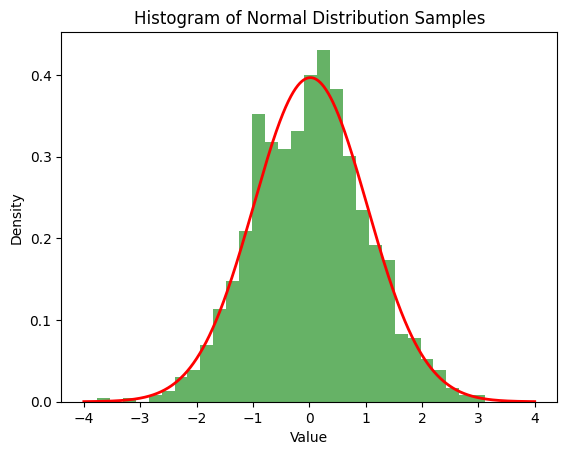

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def get_mean(samples):
    sum_samples = 0
    for sample in samples:
        sum_samples += sample
    return sum_samples / len(samples)

def get_std(samples):
    mean_value = mean(samples)
    sum_squared_diff = 0
    for sample in samples:
        sum_squared_diff += (sample - mean_value) ** 2
    return np.sqrt(sum_squared_diff / len(samples))

def main():
    samples = norm.rvs(loc=0, scale=1, size=1000) # Generate 1000 samples from a normal distribution
    mean = get_mean(samples) # Calculate the mean of the samples
    std = get_std(samples) # Calculate the standard deviation of the samples
    x = np.linspace(-4, 4, 1000) # Generate 1000 points between -4 and 4
    pdf = norm.pdf(x, loc=mean, scale=std) # Calculate the PDF of the normal distribution with the sample mean and std

    plt.hist(samples, bins=30, density=True, alpha=0.6, color='g') # Plot the histogram of the samples
    plt.plot(x, pdf, 'r-', linewidth=2) # Plot the PDF
    plt.title("Histogram of Normal Distribution Samples")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show() # Display the plot

if __name__ == "__main__":
    main()

Adapted from datasciencecourse.net

Your boss wants you to see which of these 2 logos is better:

![](abTest.jpg)

You conduct an A/B test for your website by showing A to some of your users, and B to others.
	ad clicks 	total views
A 	500 	1000
B 	550 	1000

It looks like B is better than A...

Perform a hypothesis test using the two-proportion z-value test See the "pooled" version from the table here statistic at both the 5% and 1% signficance levels.

Begin by formulating and writing down your null hypothesis, then compute the Z value for this trial, and its associated p-value.

Note: the Z value you compute is assumed to be distributed according to the standard normal distribution (mean = 0, variance = 1). We'll consider the "1-sided" p-value which meaures the probability of a sample having a Z value that is more extreme in only one tail (to get the 2-sided value, you'd just multiply by 2).

What can you conclude?
Note, to help you understand your results, you might want to tweak the number of clicks for b to see how that changes your results. For example, what do you expect to happen to your p value if b is clicked 560 or 570 times? This is JUST for understanding the results, and shouldn't bias your decision one way or another!

Increasing b's clickthrough should increase the p-value and make it so we would be likelier to fail to reject our null hypothesis at higher significance values. However, even though it would impact our Z-score and p-value, we still couldn't confirm anything with certainty.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def main():
    n_a = 1000
    n_b = 1000 # We have 1000 views for both cases
    img_a = 500 # Number of views for logo A
    img_b = 560 # Number of views for logo B

    print("Null Hypothesis: p_b = p_a (The click through rates for both logos are the same)")
    print("Alternative Hypothesis: p_b > p_a (Logo B has a higher click through rate than Logo A)")

    p_a = img_a/n_a
    p_b = img_b/n_b

    p_hat = n_a*p_a/(n_a+n_b) + n_b*p_b/(n_a+n_b)
    q_hat = 1-p_hat

    std = np.sqrt(p_hat*q_hat*(1/n_a + 1/n_b))

    if p_b == p_a:
        z = (p_b - p_a)/std
        print("H value: 0 (We are hypothesizing that the click through rates are the same)")
    elif p_b > p_a:
        z = (p_b - p_a)/std
        print("H value: 1 (We are hypothesizing that Logo B has a higher click through rate than Logo A)")
    else:
        z = (p_a - p_b)/std
        print("H value: -1 (We are hypothesizing that Logo A has a higher click through rate than Logo B)")
    

    print("Z-Score:", z)

    p_value = (1 - norm.cdf(z))

    print("P-Value:", p_value)

    

    if p_value < 0.05:
        print("Reject the null hypothesis under a 5% significance level.")
    else:
        print("Fail to reject the null hypothesis under a 5% significance level.")
    if p_value < 0.01:
        print("Reject the null hypothesis under a 1% significance level.")
    else:
        print("Fail to reject the null hypothesis under a 1% significance level.")

if __name__ == "__main__":
    main()

Null Hypothesis: p_b = p_a (The click through rates for both logos are the same)
Alternative Hypothesis: p_b > p_a (Logo B has a higher click through rate than Logo A)
H value: 1 (We are hypothesizing that Logo B has a higher click through rate than Logo A)
Z-Score: 2.238868314198227
P-Value: 0.012582242850159187
Reject the null hypothesis under a 5% significance level.
Fail to reject the null hypothesis under a 1% significance level.
